# fashion_mnist

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

# 로드
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
                'Sandal','Shirt','Sneaker','Bag','Ankle boot']


In [3]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [7]:
X_train[0].shape

X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

In [16]:
from tensorflow.keras.preprocessing import image

img = image.array_to_img(X_train[0].reshape(28, 28, 1))
img

## 데이터 탐색

0 : 9 : Ankle boot
1 : 0 : T-shirt
2 : 0 : T-shirt
3 : 3 : Dress
4 : 0 : T-shirt
5 : 2 : Pullover
6 : 7 : Sneaker
7 : 2 : Pullover
8 : 5 : Sandal
9 : 5 : Sandal
10 : 0 : T-shirt
11 : 9 : Ankle boot
12 : 5 : Sandal
13 : 5 : Sandal
14 : 7 : Sneaker
15 : 9 : Ankle boot
16 : 1 : Trouser
17 : 0 : T-shirt
18 : 6 : Shirt
19 : 4 : Coat
20 : 3 : Dress
21 : 1 : Trouser
22 : 4 : Coat
23 : 8 : Bag
24 : 4 : Coat
25 : 3 : Dress
26 : 0 : T-shirt
27 : 2 : Pullover
28 : 4 : Coat
29 : 4 : Coat
30 : 5 : Sandal
31 : 3 : Dress
32 : 6 : Shirt
33 : 6 : Shirt
34 : 0 : T-shirt
35 : 8 : Bag
36 : 5 : Sandal
37 : 2 : Pullover
38 : 1 : Trouser
39 : 6 : Shirt


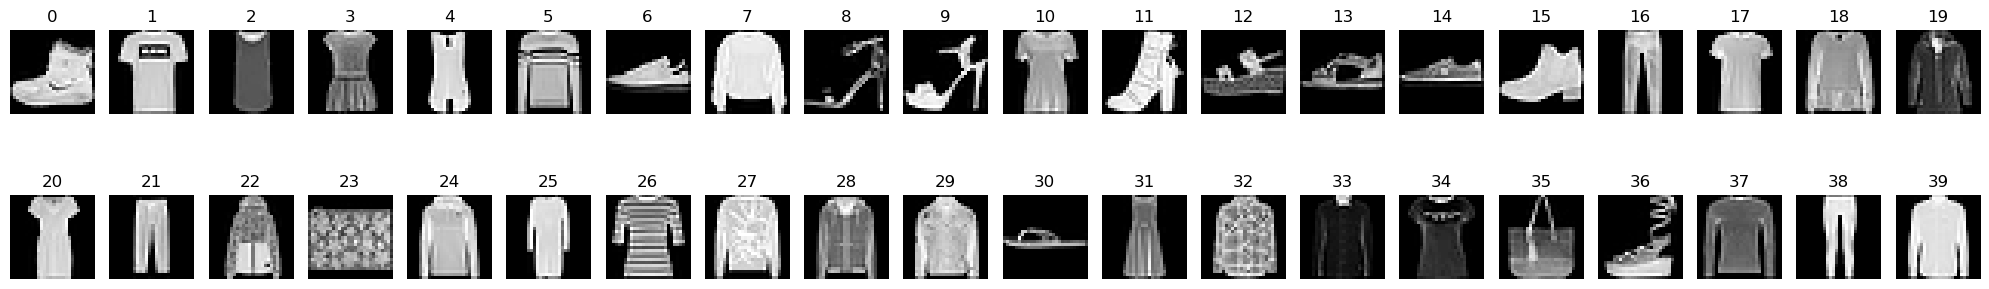

In [17]:
plt.figure(figsize=(20, 4)) # 전체 가로 길이를 길게 설정

for i in range(40):
    plt.subplot(2, 20, i + 1) # 2행 20열로 배치
    plt.imshow(X_train[i], cmap='gray')
    # plt.title(f"idx: {i}")
    plt.title(f"{i}")
    plt.axis('off')
    
    print(f"{i} : {y_train[i]} : {class_names[y_train[i]]}")

plt.tight_layout()
plt.show()

In [ ]:
# 정규화 + 채널 차원 추가 (CNN용)
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test  = X_test.reshape(-1, 28, 28, 1)  / 255.0

# One-Hot Encoding Encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test,  10)

print(X_train.shape)  # (60000, 28, 28, 1)

## 모델 생성 및 컴파일

In [32]:
from tensorflow.keras import layers, models, callbacks


# 모델 정의
model = models.Sequential([
    # 입력층
    layers.Input(shape=(28,28,1)), 
    
    # 1. 특징 추출부 (Convolution)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(), # 최적화-1 : 학습을 안정화하고 속도를 높임
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(), # 최적화-1 : 학습을 안정화하고 속도를 높임
    layers.MaxPooling2D((2, 2)),
    
    # 2. 분류부 (Dense)
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),                    # 최적화-2 : 30%의 노드를 무작위로 꺼서 과적합 방지
    
    # 출력층
    layers.Dense(10, activation='softmax') # 10개 클래스 분류
])

# 손실함수 및 최적화 설정
model.compile(optimizer='adam',
              loss='categorical_crossentropy', # for One-hot Encoding
              metrics=['accuracy'])


# # 최적화-3 : [Early Stopping 설정]
# 검증 손실(val_loss)이 3회 연속 개선되지 않으면 학습을 조기 종료합니다.
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True # 가장 성적이 좋았던 때의 가중치로 복구
)


model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,314 (477.79 KB)

 Trainable params: 122,122 (477.04 KB)

 Non-trainable params: 192 (768.00 B)

## 모델 학습 및 평가

In [45]:
history = model.fit(X_train, y_train_cat, batch_size=128, epochs=15, verbose=1,  
                    # validation_split=0.2, : 테스트 용 데이터가 없을 시
                    validation_data=(X_test, y_test_cat),
                    callbacks=[early_stopping]   # 최적화-3 : [Early Stopping 설정]
)

loss, accuracy = model.evaluate(X_test, y_test_cat, verbose=0)

print(f'Test loss: {loss}, Test accuracy: {accuracy}')

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9140 - loss: 0.2280 - val_accuracy: 0.8962 - val_loss: 0.2969
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9216 - loss: 0.2104 - val_accuracy: 0.8883 - val_loss: 0.3084
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9270 - loss: 0.1943 - val_accuracy: 0.8999 - val_loss: 0.2905
Test loss: 0.29682332277297974, Test accuracy: 0.8962000012397766


# 검증 결과

* 기본 설정 : Hidden Layer 2개, 32 -> 64
Test loss: 1.0383648872375488, Test accuracy: 0.8952999711036682

* 최적화 적용 후 : Drop, batch_normalization, early_stopping 추가
Test loss: 0.2654626965522766, Test accuracy: 0.900600016117096

# 학습 곡선 비교

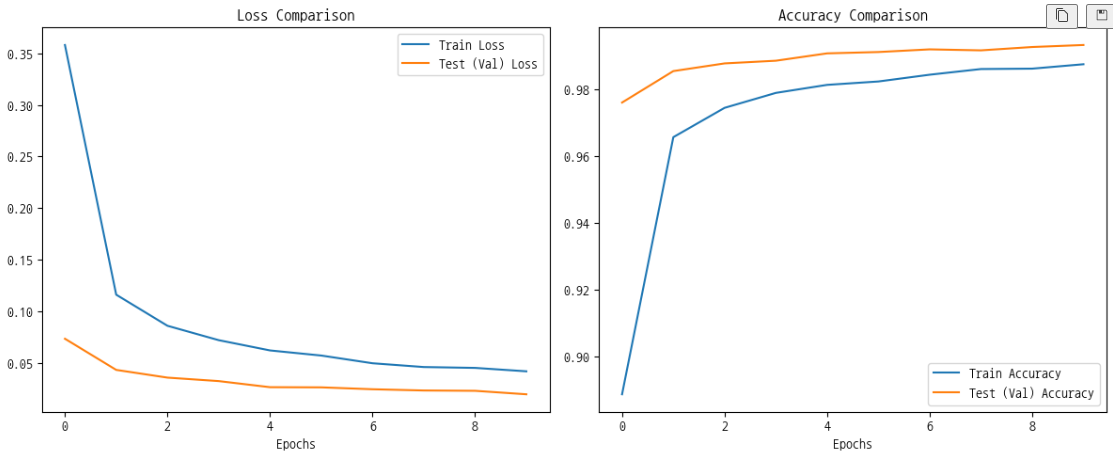

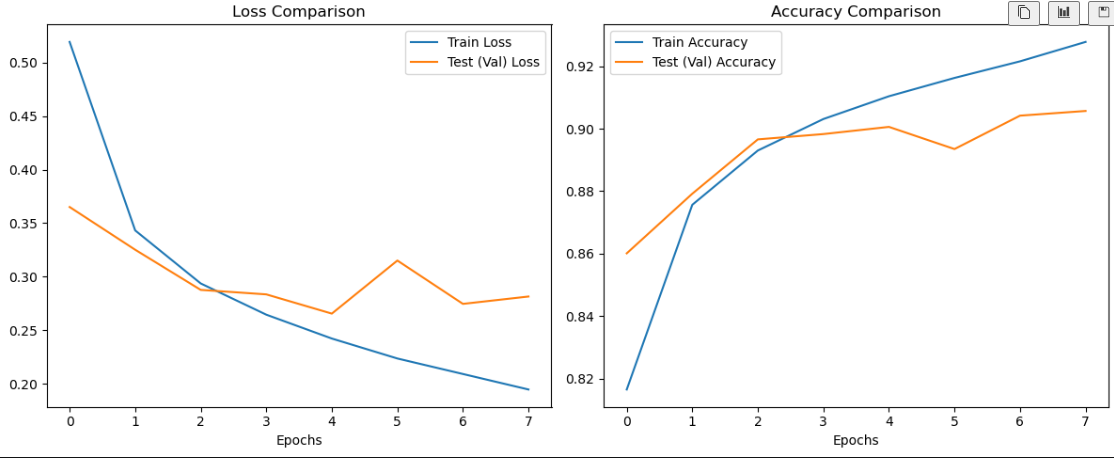

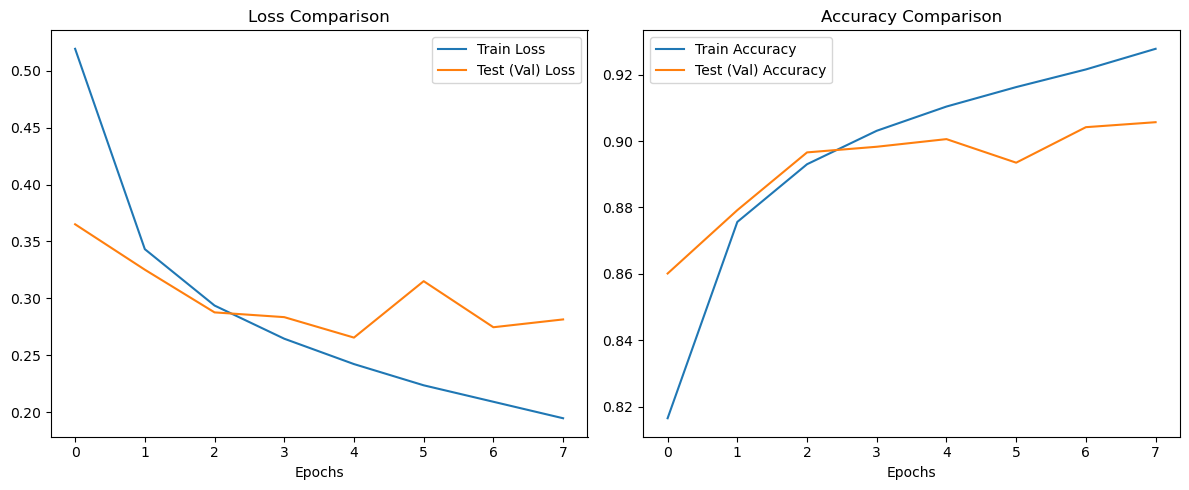

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 1. Loss 비교 (훈련 vs 테스트)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test (Val) Loss')
plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.legend()

# 2. Accuracy 비교 (훈련 vs 테스트)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test (Val) Accuracy')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.legend()

plt.tight_layout()
plt.show()

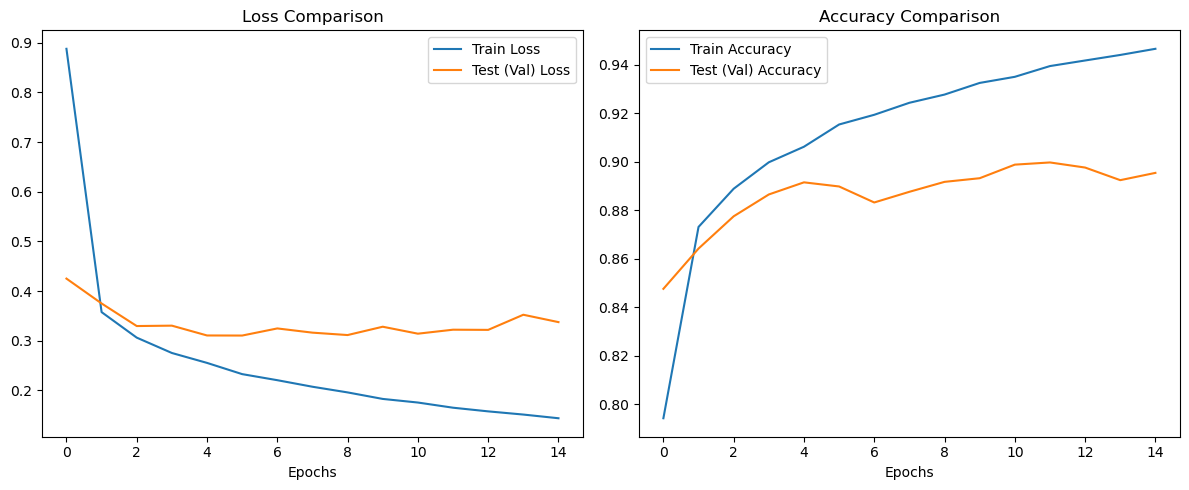

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 1. Loss 비교 (훈련 vs 테스트)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test (Val) Loss')
plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.legend()

# 2. Accuracy 비교 (훈련 vs 테스트)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test (Val) Accuracy')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.legend()

plt.tight_layout()
plt.show()

## 성능평가 해석 (개선 전)

- 과적합 단계 : 4,5 단계 이후 Test Loss 및 정확도 정체

### 성능을 더 올리기 위한 해결책
- 드롭아웃(Dropout) 추가: Dense 레이어 직전에 layers.Dropout(0.3) 정도를 추가해 보세요. 특정 노드에 의존하는 것을 방지해 과적합을 효과적으로 막아줍니다.
- 데이터 증강(Data Augmentation): 이미지 분류에서 아주 효과적입니다. 이미지를 살짝 회전하거나 밀어서 데이터의 다양성을 높여보세요.
- 배치 정규화(Batch Normalization): Conv2D 레이어 다음에 layers.BatchNormalization()을 넣으면 학습이 더 안정화되고 성능이 올라가는 경우가 많습니다.
- Early Stopping 적용: 테스트 손실이 더 이상 줄어들지 않을 때 자동으로 학습을 멈추게 설정하여 최적의 상태에서 모델을 저장할 수 있습니다.

## 모델이 틀린 경우 확인

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


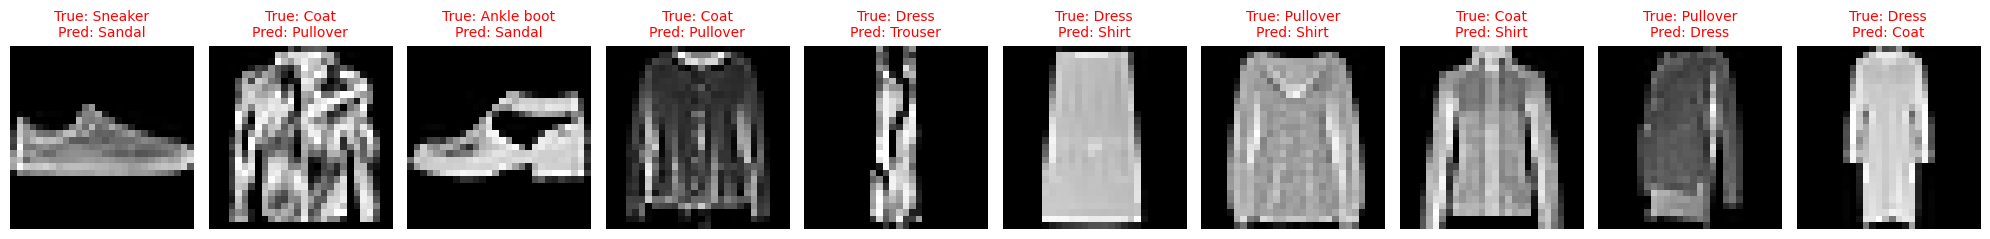

전체 테스트 데이터 10000개 중 994개를 틀렸습니다.
에러율: 9.94%


In [35]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 모델로 테스트 데이터 예측하기
# 결과는 각 클래스별 확률로 나오므로, 가장 높은 확률의 인덱스를 추출합니다.
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 실제 정답(숫자 형태) 가져오기
y_true = np.argmax(y_test_cat, axis=1)

# 2. 틀린 데이터의 인덱스 찾기
misclassified_idx = np.where(y_pred != y_true)[0]

# 3. 틀린 이미지 중 앞의 10개 시각화
plt.figure(figsize=(20, 4))

for i, idx in enumerate(misclassified_idx[:10]):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    
    # 제목 설정 (정답 vs 예측)
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    plt.title(f"True: {true_label}\nPred: {pred_label}", color='red', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

# 4. 전체 에러율 확인
print(f"전체 테스트 데이터 {len(X_test)}개 중 {len(misclassified_idx)}개를 틀렸습니다.")
print(f"에러율: {len(misclassified_idx)/len(X_test)*100:.2f}%")


## 혼동행렬을 이용한 틀린 쌍 조회

In [41]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# 1. 예측값과 실제값 준비 (이미 y_pred, y_true가 있다면 그대로 사용)
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# 2. 혼동 행렬 생성
cm = confusion_matrix(y_true, y_pred)

# 3. 오답 데이터만 추출하여 리스트화
errors = []
for i in range(10): # 실제 정답 루프
    for j in range(10): # 예측값 루프
        if i != j and cm[i][j] > 0: # 정답이 아니면서 틀린 횟수가 있는 경우
            errors.append({
                'True': class_names[i],
                'Predict': class_names[j],
                'Count': cm[i][j]
            })

# 4. 횟수(Count) 기준으로 내림차순 정렬
error_df = pd.DataFrame(errors).sort_values(by='Count', ascending=False)

print("--- [가장 자주 발생하는 오답 TOP 10] ---")
print(error_df.head(10).to_string(index=False))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- [가장 자주 발생하는 오답 TOP 10] ---
      True  Predict  Count
   T-shirt    Shirt    169
  Pullover    Shirt     92
     Shirt  T-shirt     82
      Coat    Shirt     82
  Pullover     Coat     66
     Shirt     Coat     57
     Dress    Shirt     47
     Shirt Pullover     46
Ankle boot  Sneaker     33
     Dress     Coat     32


## 혼동행렬 시각화 : Heatmap

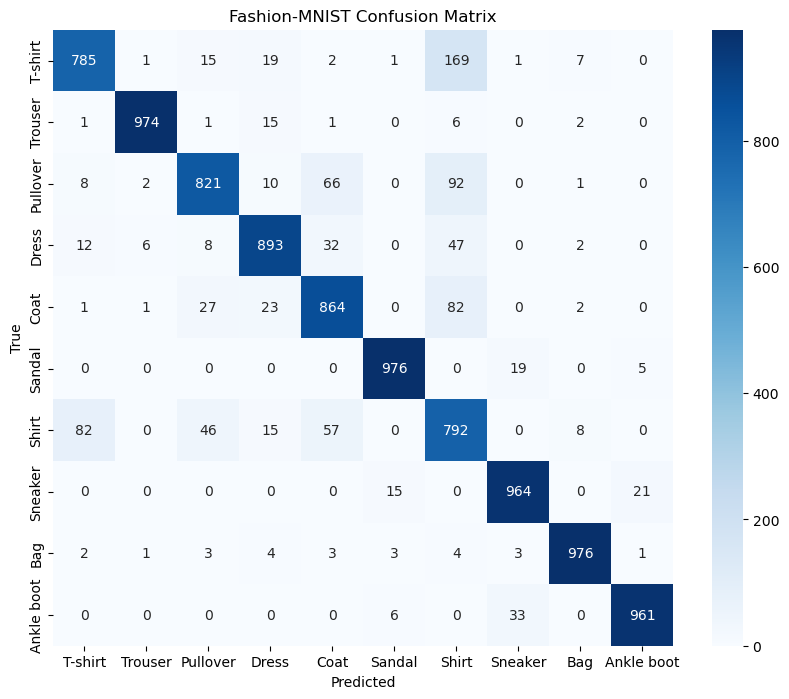

In [42]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Fashion-MNIST Confusion Matrix')
plt.show()

## 틀린쌍 강조 시각화

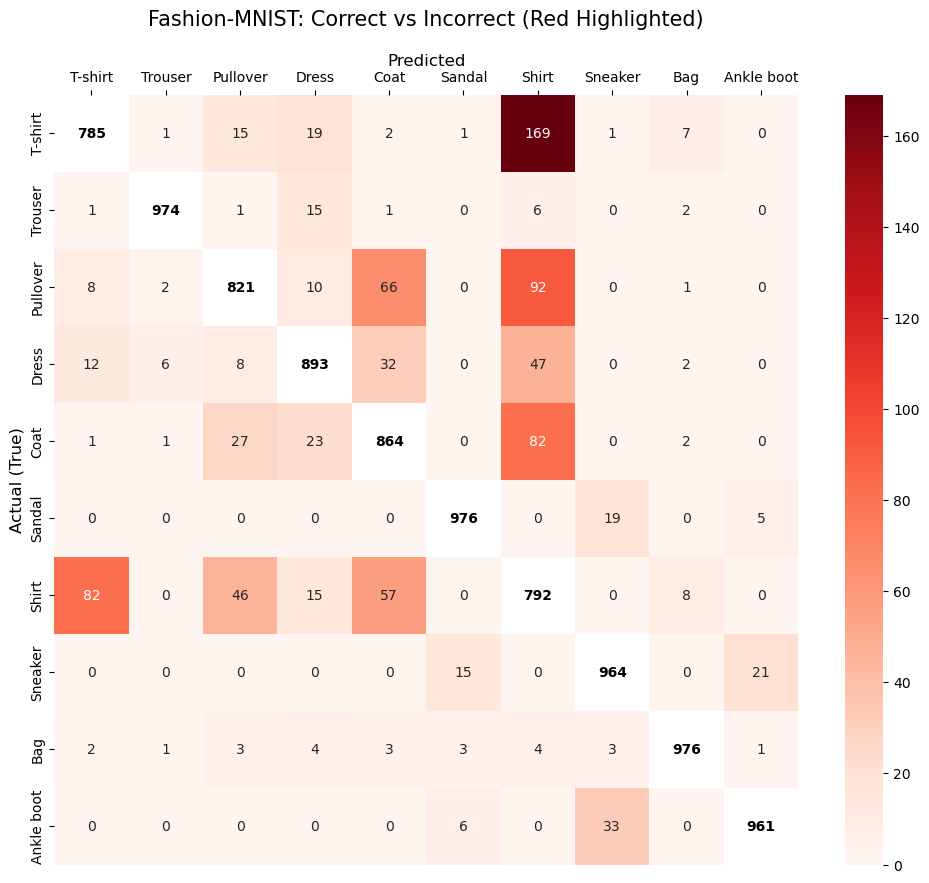

In [44]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 1. 혼동 행렬 데이터 복사
cm_mask = cm.astype('float')

# 2. 마스크 생성
mask = np.eye(10, dtype=bool)

# 3. 시각화 설정
plt.figure(figsize=(12, 10))

# 4. 히트맵 그리기
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', mask=mask, cbar=True,
            xticklabels=class_names, yticklabels=class_names)

# --- x축을 상단으로 이동하는 코드 ---
ax.xaxis.tick_top() # x축 눈금을 위로
ax.xaxis.set_label_position('top') # x축 레이블을 위로
# ------------------------------

# 5. 대각선(정답) 부분 숫자 표시
for i in range(10):
    plt.text(i + 0.5, i + 0.5, str(cm[i, i]), 
             ha='center', va='center', color='black', fontweight='bold')

plt.title('Fashion-MNIST: Correct vs Incorrect (Red Highlighted)', fontsize=15, pad=20)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual (True)', fontsize=12)
plt.show()

